In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

#### SEP在基因组上的分布
去看每个sORF都落在参考基因组注释的什么区域

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ================= 1. 配置路径 =================
CSV_PATH = "/data/user_home/2023122004/FFTransformer/protein/predict_sorf/Z.mays/Pann_Annotation.csv"

df = pd.read_csv(CSV_PATH)
df


,ID,seqid,start,end,strand,Length_bp,Region_Category,DNA_Sequence,attributes
0,sorf_1_1,1,35062,35310,+,249,CDS,ATGGCGTCCGCGAGCTGGACGAGCTTGGCCTCTGGGCGTCGTGGAG...,ID=sorf_1_1;len=249;conf=1.00;start_codon=ATG
1,sorf_1_2,1,36108,36140,+,33,CDS,GATGATGACATACTTATCAATACCTGCAGATGA,ID=sorf_1_2;len=33;conf=1.00;start_codon=GAT
2,sorf_1_3,1,36272,36379,+,108,CDS,ATGGTGGTGTTAGCATGTTGGGACATGGAGATGTGTCATTTCCTTA...,ID=sorf_1_3;len=108;conf=1.00;start_codon=ATG
3,sorf_1_4,1,36916,36981,+,66,CDS,ATGTTCTGGGCATCAGTAAAAAAATGGTGGTTCCAGTCATTACATC...,ID=sorf_1_4;len=66;conf=1.00;start_codon=ATG
4,sorf_1_5,1,37451,37486,+,36,CDS,GAAAACAACAGGAAAAATTCTGTGTCGTTCGCCTGA,ID=sorf_1_5;len=36;conf=1.00;start_codon=GAA
...,...,...,...,...,...,...,...,...,...
64812,sorf_9_11504,9,162504130,162504171,+,42,Intergenic,ATGGCAAGCATTTGTGGGTGTTGGTGCTCGAAGGATTCCTAG,ID=sorf_9_11504;len=42;conf=1.00;start_codon=ATG
64813,sorf_9_11505,9,162505005,162505055,+,51,CDS,ATGGATCTGTTGACGAGGGTGTGGCTTATTTTGTTGAGTGGGCTAT...,ID=sorf_9_11505;len=51;conf=1.00;start_codon=ATG
64814,sorf_9_11506,9,162505216,162505248,+,33,CDS,ATGTGGAATCATCAAAGTGATTGCAAGAATTGA,ID=sorf_9_11506;len=33;conf=1.00;start_codon=ATG
64815,sorf_9_11507,9,162510493,162510552,+,60,doORF,ATGGTACCTCTCGTAATTCATCCCGTTATGGAGATTTTGATGAAGA...,ID=sorf_9_11507;len=60;conf=1.00;start_codon=ATG


检测到的分类 (Region_Category): ['CDS' '3UTR' 'Intergenic' 'doORF' 'uoORF' '5UTR' 'lncRNA']
正在绘制分类: CDS (半径: 60-68)
正在绘制分类: 5UTR (半径: 50-58)
正在绘制分类: 3UTR (半径: 40-48)
正在绘制分类: Intergenic (半径: 30-38)
正在绘制分类: doORF (半径: 20-28)
正在绘制分类: uoORF (半径: 10-18)
正在绘制分类: lncRNA (半径: 0-8)


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

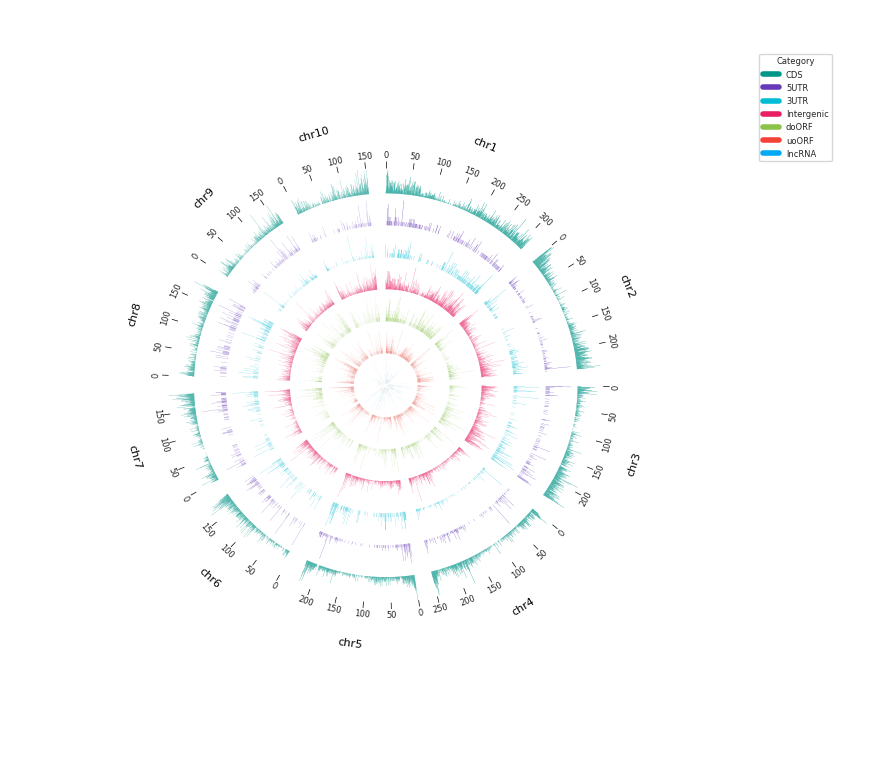

In [30]:
from pycirclize import Circos
df['seqid'] = df['seqid'].astype(str)

print("检测到的分类 (Region_Category):", df['Region_Category'].unique())

MAIZE_CHROM_LENGTHS_MB = {
    '1': 308.45, '2': 243.68, '3': 238.01, '4': 250.33, '5': 226.35,
    '6': 181.36, '7': 185.81, '8': 182.41, '9': 163.00, '10': 152.44
}

sector_dict = {}
for chrom_id, length_mb in MAIZE_CHROM_LENGTHS_MB.items():
    name = f"chr{chrom_id}"
    length_bp = length_mb * 1_000_000
    sector_dict[name] = length_bp

circos = Circos(sectors=sector_dict, space=5)

category_colors = {
    'CDS':    '#009688',     
    'Intron': '#607D8B',       
    '5UTR': '#673AB7',  
    '3UTR' : '#00BCD4',
    'Intergenic':   '#E91E63', 
    'doORF': '#8BC34A', 
    'uoORF': '#F44336', 
    'lncRNA': '#03A9F4',       
}


available_cats = [cat for cat in category_colors.keys() if cat in df['Region_Category'].unique()]
categories_to_plot = available_cats 


r_current = 68  # 起始半径 (百分比)
r_height = 8    # 每个轨道的高度
r_spacing = 2   # 轨道之间的间隙

for cat in categories_to_plot:
    color = category_colors.get(cat, 'grey') 

    r_start = r_current - r_height
    r_end = r_current
    
    print(f"正在绘制分类: {cat} (半径: {r_start}-{r_end})")
    
    for sector in circos.sectors:

        track = sector.add_track((r_start, r_end))
        track.axis(fc="none", ec="none") 

        current_seqid = sector.name.replace("chr", "")

        sub_df = df[(df['seqid'] == current_seqid) & (df['Region_Category'] == cat)]
        
        if not sub_df.empty:

            hist_counts, bin_edges = np.histogram(sub_df['start'], bins=500, range=(0, sector.size))

            x_pos = bin_edges[:-1] + (bin_edges[1] - bin_edges[0]) / 2
            bar_width = (bin_edges[1] - bin_edges[0])

            track.bar(x_pos, hist_counts, width=bar_width, color=color, lw=0)

    r_current -= (r_height + r_spacing)

for sector in circos.sectors:

    sector.text(sector.name, r=80, size=8, color="black")

    if len(sector.tracks) > 0:
        track = sector.tracks[0] 

        major_interval = 50 * 1_000_000  # 50 Mb
        
        track.xticks_by_interval(
            interval=major_interval,
            outer=True,   
            label_size=6,
            label_formatter=lambda v: f"{v / 1_000_000:.0f}" 
        )

fig = circos.plotfig()

handles = [plt.Line2D([], [], color=category_colors.get(c, 'grey'), label=c, linewidth=4) 
           for c in categories_to_plot]
plt.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left', title="Category")


# # plt.show()
plt.savefig('Region_Category.pdf',dpi=1000)
plt.savefig('Region_Category.png',dpi=1000)

In [31]:
df['Start_Codon'] = df['DNA_Sequence'].astype(str).str[:3].str.upper()

df['Codon_Type'] = df['Start_Codon'].apply(lambda x: 'ATG' if x == 'ATG' else 'Non-ATG')

top_regions = df['Region_Category'].value_counts().nlargest(10).index.tolist()
df_plot = df[df['Region_Category'].isin(top_regions)].copy()


stats = df_plot.groupby(['Region_Category', 'Codon_Type']).size().reset_index(name='Count')

region_totals = stats.groupby('Region_Category')['Count'].sum()
sort_order = region_totals.sort_values(ascending=False).index.tolist()

print("\n[统计结果预览]:")
print(stats)


[统计结果预览]:
   Region_Category Codon_Type  Count
0             3UTR        ATG    439
1             3UTR    Non-ATG   1139
2             5UTR        ATG    408
3             5UTR    Non-ATG    998
4              CDS        ATG  17441
5              CDS    Non-ATG  24118
6       Intergenic        ATG   3672
7       Intergenic    Non-ATG  10358
8            doORF        ATG   1021
9            doORF    Non-ATG   1502
10          lncRNA        ATG    274
11          lncRNA    Non-ATG    385
12           uoORF        ATG    984
13           uoORF    Non-ATG   2078


In [32]:
stats['Region_Category'] = stats['Region_Category'].apply(
    lambda x: 'lncRNA' if 'lncRNA' in x else x
)
# stats['Region_Category'] = stats['Region_Category'].apply(
#     lambda x: 'CDS' if 'CDS' in x else x
# )
stats = stats.groupby(
    ['Region_Category', 'Codon_Type'],
    as_index=False
)['Count'].sum()

stats

,Region_Category,Codon_Type,Count
0,3UTR,ATG,439
1,3UTR,Non-ATG,1139
2,5UTR,ATG,408
3,5UTR,Non-ATG,998
4,CDS,ATG,17441
5,CDS,Non-ATG,24118
6,Intergenic,ATG,3672
7,Intergenic,Non-ATG,10358
8,doORF,ATG,1021
9,doORF,Non-ATG,1502


In [33]:
region_totals = stats.groupby('Region_Category')['Count'].sum()

sort_order = region_totals.sort_values(ascending=False).index.tolist()
sort_order


['CDS', 'Intergenic', 'uoORF', 'doORF', '3UTR', '5UTR', 'lncRNA']

In [34]:
plot_df = stats.pivot(
    index='Region_Category',
    columns='Codon_Type',
    values='Count'
).fillna(0)

plot_df = plot_df.loc[sort_order]

print(plot_df)


Codon_Type         ATG  Non-ATG
Region_Category                
CDS              17441    24118
Intergenic        3672    10358
uoORF              984     2078
doORF             1021     1502
3UTR               439     1139
5UTR               408      998
lncRNA             274      385


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

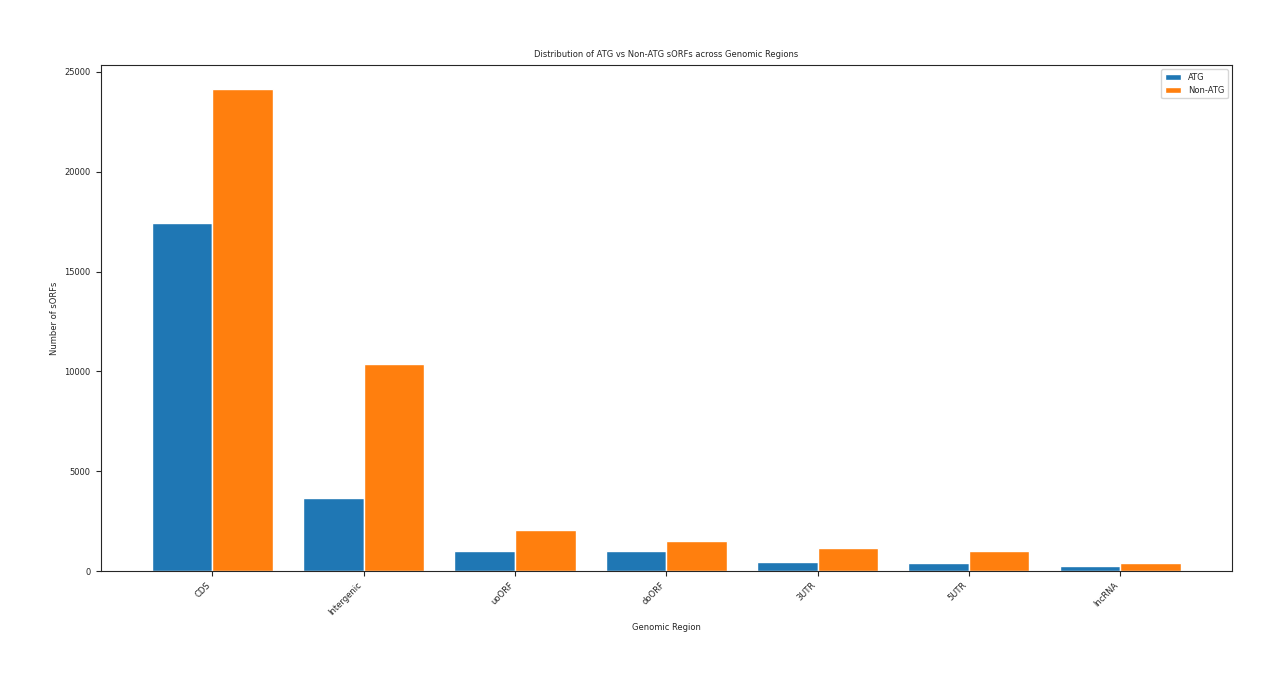

In [35]:
import matplotlib.pyplot as plt
import numpy as np

regions = plot_df.index.tolist()
x = np.arange(len(regions))

width = 0.4

atg_counts = plot_df['ATG'].values
nonatg_counts = plot_df['Non-ATG'].values

plt.figure(figsize=(12, 6))

plt.bar(x - width/2, atg_counts, width, label='ATG')
plt.bar(x + width/2, nonatg_counts, width, label='Non-ATG')

plt.xticks(x, regions, rotation=45, ha='right')
plt.ylabel('Number of sORFs')
plt.xlabel('Genomic Region')
plt.title('Distribution of ATG vs Non-ATG sORFs across Genomic Regions')
plt.legend()

plt.tight_layout()
plt.show()

In [36]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, fisher_exact
from statsmodels.stats.multitest import multipletests

global_ATG = plot_df['ATG'].sum()
global_NonATG = plot_df['Non-ATG'].sum()
global_total = global_ATG + global_NonATG
global_ATG_ratio = global_ATG / global_total
global_ATG_ratio
results = []

for region, row in plot_df.iterrows():
    a = row['ATG']
    b = row['Non-ATG']
    c = global_ATG - a
    d = global_NonATG - b

    contingency = [[a, b],
                   [c, d]]

    # 小样本用 Fisher，
    if min(a, b, c, d) < 5:
        oddsratio, p = fisher_exact(contingency)
        test = "Fisher"
    else:
        chi2, p, dof, exp = chi2_contingency(contingency)
        test = "Chi-square"

    results.append([
        region,
        a,
        b,
        a / (a + b),
        global_ATG_ratio,
        test,
        p
    ])

stats_df = pd.DataFrame(
    results,
    columns=[
        "Region",
        "ATG",
        "Non-ATG",
        "Region_ATG_ratio",
        "Global_ATG_ratio",
        "Test",
        "p_value"
    ]
)

# 多重检验校正（FDR）
stats_df["FDR"] = multipletests(stats_df["p_value"], method="fdr_bh")[1]

# 显著性强度
stats_df["minus_log10_FDR"] = -np.log10(stats_df["FDR"])

# 按显著性排序
stats_df = stats_df.sort_values("FDR")

print(stats_df)

       Region    ATG  Non-ATG  Region_ATG_ratio  Global_ATG_ratio        Test  \
0         CDS  17441    24118          0.419668          0.373961  Chi-square   
1  Intergenic   3672    10358          0.261725          0.373961  Chi-square   
4        3UTR    439     1139          0.278200          0.373961  Chi-square   
5        5UTR    408      998          0.290185          0.373961  Chi-square   
2       uoORF    984     2078          0.321359          0.373961  Chi-square   
3       doORF   1021     1502          0.404677          0.373961  Chi-square   
6      lncRNA    274      385          0.415781          0.373961  Chi-square   

         p_value            FDR  minus_log10_FDR  
0  1.195347e-226  8.367430e-226       225.077408  
1  2.150191e-211  7.525667e-211       210.123455  
4   2.139055e-15   4.991128e-15        14.301801  
5   6.319104e-11   1.105843e-10         9.956306  
2   8.048620e-10   1.126807e-09         8.948151  
3   1.230723e-03   1.435843e-03         2.842

In [37]:
import numpy as np

plot_df['log2_NonATG_vs_ATG'] = np.log2(
    (plot_df['Non-ATG'] + 1e-9) / (plot_df['ATG'] + 1e-9)
)

fc_df = plot_df[['log2_NonATG_vs_ATG']].sort_values(
    'log2_NonATG_vs_ATG', ascending=False
)

print(fc_df)


Codon_Type       log2_NonATG_vs_ATG
Region_Category                    
Intergenic                 1.496107
3UTR                       1.375475
5UTR                       1.290471
uoORF                      1.078465
doORF                      0.556902
lncRNA                     0.490683
CDS                        0.467628


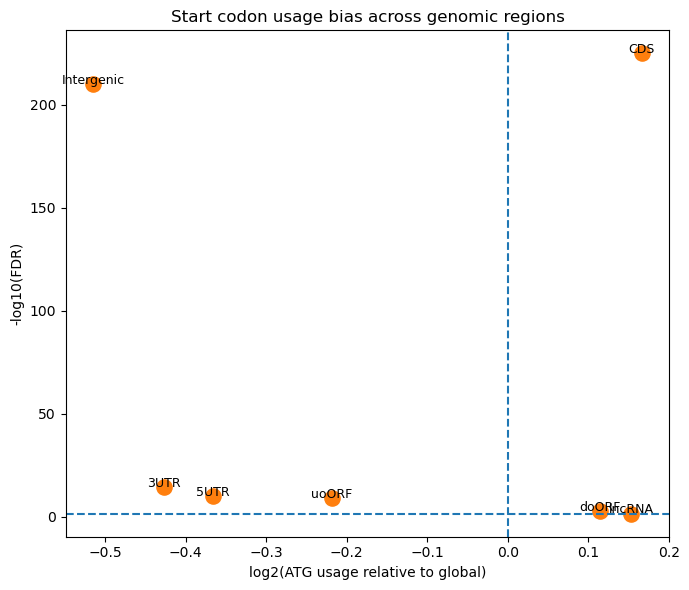

In [38]:
plt.style.use("default")   
stats_df["ATG_bias_log2"] = np.log2(
    stats_df["Region_ATG_ratio"] / stats_df["Global_ATG_ratio"]
)

import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

# 所有点
plt.scatter(
    stats_df["ATG_bias_log2"],
    stats_df["minus_log10_FDR"],
    s=80
)

sig = stats_df["FDR"] < 0.05
plt.scatter(
    stats_df.loc[sig, "ATG_bias_log2"],
    stats_df.loc[sig, "minus_log10_FDR"],
    s=120
)

for _, row in stats_df.iterrows():
    plt.text(
        row["ATG_bias_log2"],
        row["minus_log10_FDR"] + 0.1,
        row["Region"],
        ha="center",
        fontsize=9
    )

plt.axhline(-np.log10(0.05), linestyle="--")
plt.axvline(0, linestyle="--")

plt.xlabel("log2(ATG usage relative to global)")
plt.ylabel("-log10(FDR)")
plt.title("Start codon usage bias across genomic regions")
# plt.grid()
plt.tight_layout()
plt.show()


       Region  Total
0         CDS  41559
1  Intergenic  14030
2        3UTR   1578
3        5UTR   1406
4       uoORF   3062


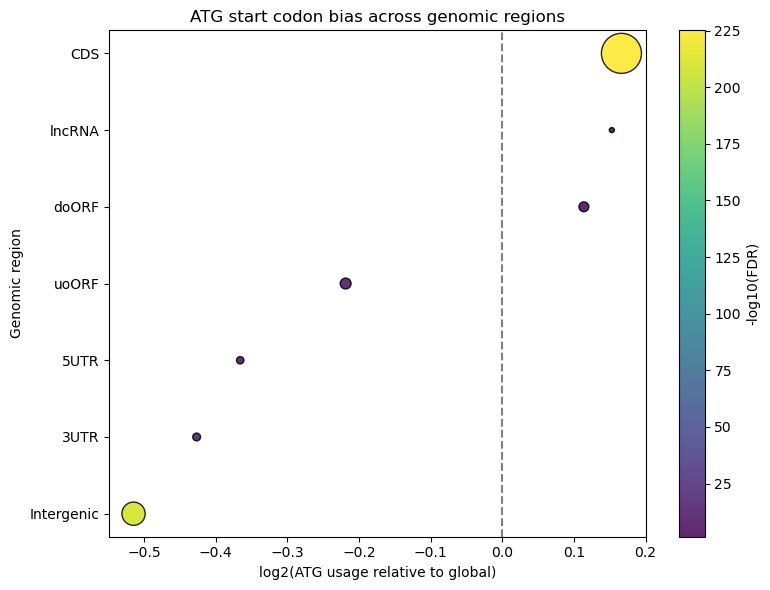

In [39]:
plot_df = stats.pivot(
    index='Region_Category',
    columns='Codon_Type',
    values='Count'
).fillna(0)

plot_df = plot_df.loc[sort_order]

plot_df["Total"] = plot_df.sum(axis=1) 

plot_df2 = plot_df.reset_index()

bubble_df = stats_df.merge(
    plot_df2[["Region_Category", "Total"]],
    left_on="Region",
    right_on="Region_Category",
    how="left"
)

print(bubble_df[["Region", "Total"]].head())

bubble_df = stats_df.merge(
    plot_df2[["Region_Category", "Total"]],
    left_on="Region",
    right_on="Region_Category",
    how="left"
)

plot_df2 = plot_df.reset_index()  

bubble_df = stats_df.merge(
    plot_df2[["Region_Category", "Total"]],
    left_on="Region",
    right_on="Region_Category",
    how="left"
)
bubble_df[["Region", "Total"]]
import matplotlib.pyplot as plt

bubble_df = bubble_df.sort_values("ATG_bias_log2")

y_pos = range(len(bubble_df))

plt.figure(figsize=(8,6))

plt.scatter(
    bubble_df["ATG_bias_log2"],
    y_pos,
    s=bubble_df["Total"] * 0.02,
    c=bubble_df["minus_log10_FDR"],  
    cmap="viridis",
    edgecolors="black",
    alpha=0.85
)

plt.yticks(y_pos, bubble_df["Region"])
plt.axvline(0, linestyle="--", color="gray")

plt.xlabel("log2(ATG usage relative to global)")
plt.ylabel("Genomic region")
plt.title("ATG start codon bias across genomic regions")

cbar = plt.colorbar()
cbar.set_label("-log10(FDR)")

plt.tight_layout()
plt.show()


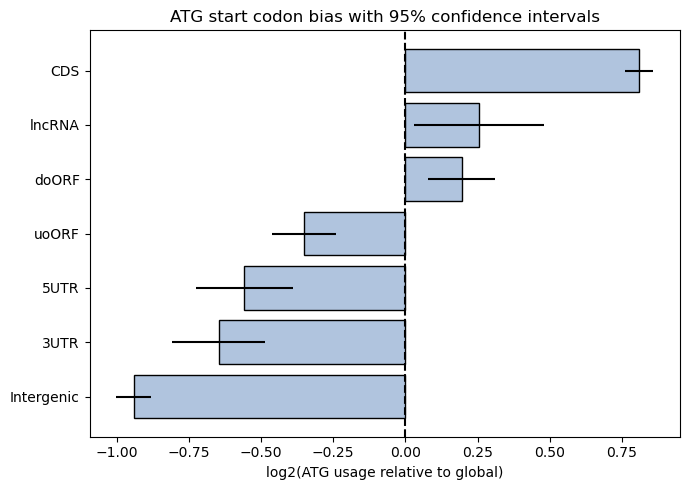

In [40]:
import numpy as np

# 全局计数
A = stats_df["ATG"].sum()
B = stats_df["Non-ATG"].sum()

ci_rows = []

for _, row in stats_df.iterrows():
    a = row["ATG"]
    b = row["Non-ATG"]
    c = A - a
    d = B - b

    log_or = np.log((a * d) / (b * c))
    se = np.sqrt(1/a + 1/b + 1/c + 1/d)

    ci_low = log_or - 1.96 * se
    ci_high = log_or + 1.96 * se

    ci_rows.append([row["Region"], log_or/np.log(2), ci_low/np.log(2), ci_high/np.log(2), row["FDR"]])

ci_df = pd.DataFrame(
    ci_rows,
    columns=["Region", "log2FC", "CI_low", "CI_high", "FDR"]
)

ci_df = ci_df.sort_values("log2FC")
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

y = range(len(ci_df))

plt.barh(
    y,
    ci_df["log2FC"],
    xerr=[ci_df["log2FC"] - ci_df["CI_low"],
          ci_df["CI_high"] - ci_df["log2FC"]],
    color="lightsteelblue",
    edgecolor="black"
)

plt.yticks(y, ci_df["Region"])
plt.axvline(0, linestyle="--", color="black")

plt.xlabel("log2(ATG usage relative to global)")
plt.title("ATG start codon bias with 95% confidence intervals")

plt.tight_layout()
plt.show()


In [13]:
import pandas as pd

data = pd.DataFrame({
    "Region": ["CDS", "Intergenic", "Intron", "uoORF", "doORF", "3UTR", "5UTR", "lncRNA"],
    "ATG": [17433, 2912, 792, 984, 1021, 437, 408, 252],
    "nonATG": [24103, 7694, 2705, 2078, 15023, 11395, 998, 359]
})

data["Total"] = data["ATG"] + data["nonATG"]
data

,Region,ATG,nonATG,Total
0,CDS,17433,24103,41536
1,Intergenic,2912,7694,10606
2,Intron,792,2705,3497
3,uoORF,984,2078,3062
4,doORF,1021,15023,16044
5,3UTR,437,11395,11832
6,5UTR,408,998,1406
7,lncRNA,252,359,611


In [14]:
total_ATG = data["ATG"].sum()
total_nonATG = data["nonATG"].sum()
total_ATG, total_nonATG
from scipy.stats import fisher_exact

results = []

for i, row in data.iterrows():
    a = row["ATG"]
    b = row["nonATG"]
    c = total_ATG - a
    d = total_nonATG - b
    
    table = [[a, b],
             [c, d]]
    
    OR, p = fisher_exact(table, alternative="two-sided")
    
    results.append([row["Region"], a, b, OR, p])

res = pd.DataFrame(results, columns=["Region", "ATG", "nonATG", "OddsRatio", "Pvalue"])
res


,Region,ATG,nonATG,OddsRatio,Pvalue
0,CDS,17433,24103,4.277564,0.000000e+00
1,Intergenic,2912,7694,1.005527,8.164224e-01
2,Intron,792,2705,0.769846,9.752852e-11
3,uoORF,984,2078,1.268122,3.091673e-09
4,doORF,1021,15023,0.144402,0.000000e+00
5,3UTR,437,11395,0.085330,0.000000e+00
6,5UTR,408,998,1.086881,1.654051e-01
7,lncRNA,252,359,1.872764,1.406410e-13


,Region,ATG,nonATG,OddsRatio,Pvalue,FDR,Bias
0,CDS,17433,24103,4.277564,0.000000e+00,0.000000e+00,ATG_enriched
4,doORF,1021,15023,0.144402,0.000000e+00,0.000000e+00,nonATG_enriched
5,3UTR,437,11395,0.085330,0.000000e+00,0.000000e+00,nonATG_enriched
7,lncRNA,252,359,1.872764,1.406410e-13,2.812820e-13,ATG_enriched
2,Intron,792,2705,0.769846,9.752852e-11,1.560456e-10,nonATG_enriched
3,uoORF,984,2078,1.268122,3.091673e-09,4.122230e-09,ATG_enriched
6,5UTR,408,998,1.086881,1.654051e-01,1.890344e-01,Not_significant
1,Intergenic,2912,7694,1.005527,8.164224e-01,8.164224e-01,Not_significant


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

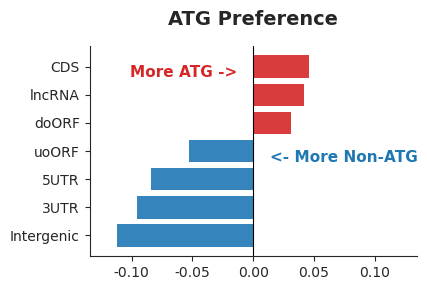

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("ticks") 
plt.rcParams['font.sans-serif'] = ['Arial'] 
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.grid'] = False 
df = stats_df.copy() 
df['Diff'] = df['Region_ATG_ratio'] - df['Global_ATG_ratio']
df['Color'] = df['Diff'].apply(lambda x: '#d62728' if x > 0 else '#1f77b4')
fig = plt.figure(figsize=(8, 3))
ax1 = fig.add_subplot(121) 
df_sorted = df.sort_values('Diff')
bars = ax1.barh(df_sorted['Region'], df_sorted['Diff'], color=df_sorted['Color'], alpha=0.9, edgecolor='none')
ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax1.set_title('ATG Preference', fontsize=14, fontweight='bold', pad=15)
xlim = max(abs(df_sorted['Diff'].min()), abs(df_sorted['Diff'].max())) * 1.2
ax1.set_xlim(-xlim, xlim)
ax1.text( 0.45,0.85, 'More ATG ->', transform=ax1.transAxes, color='#d62728', 
         fontweight='bold', ha='right', fontsize=11)
ax1.text(0.55, 0.45, '<- More Non-ATG', transform=ax1.transAxes, color='#1f77b4', 
         fontweight='bold', ha='left', fontsize=11)
sns.despine(ax=ax1)


# ax2 = fig.add_subplot(122) 

# sizes = np.sqrt(df['minus_log10_FDR']) * 30 + 50 

# scatter = ax2.scatter(df['Region'], df['Region_ATG_ratio'], 
#                       s=sizes, 
#                       c=df['Color'], 
#                       alpha=0.8, 
#                       edgecolors='black', # 气泡边缘加黑线，无网格时更突出
#                       linewidth=0.8)

# ax2.axhline(y=0.374, color='gray', linestyle='--', linewidth=1.5, label='Global Baseline (0.374)')

# # for i, row in df.iterrows():
# #     if row['minus_log10_FDR'] > 100:
# #         ax2.text(row['Region'], row['Region_ATG_ratio'] + 0.01, 
# #                  f"P<{1e-100}", ha='center', va='bottom', fontsize=9, color='black')

# ax2.set_title('Ratio vs Significance', fontsize=14, fontweight='bold', pad=15)
# ax2.set_ylabel('ATG Start Codon Ratio', fontsize=12)
# # 适当放宽Y轴视野
# y_min, y_max = df['Region_ATG_ratio'].min(), df['Region_ATG_ratio'].max()
# ax2.set_ylim(y_min - 0.05, y_max + 0.05)

# ax2.legend(loc='upper right', frameon=False) # frameon=False 去掉图例的边框

# sns.despine(ax=ax2)

# ================= 4. 最终调整 =================
plt.tight_layout()
plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

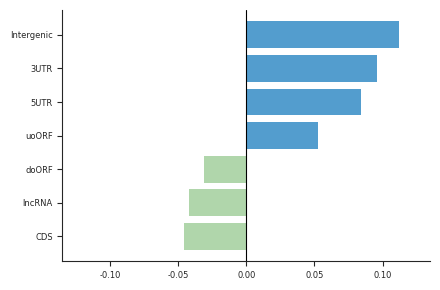

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("ticks")
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.grid'] = False

df = stats_df.copy()

df['Diff'] = df['Global_ATG_ratio'] - df['Region_ATG_ratio']

df['Color'] = np.where(df['Diff'] < 0, '#a8d2a2', '#4092c9'  )

df_sorted = df.sort_values('Diff')

fig, ax = plt.subplots(figsize=(4.5, 2.5), dpi=1300)

ax.barh(
    df_sorted['Region'],
    df_sorted['Diff'],
    color=df_sorted['Color'],
    alpha=0.9,
    edgecolor='none'
)


ax.axvline(0, color='black', linewidth=0.8)

# ax.set_title('ATG Preference', fontsize=6)

xlim = np.max(np.abs(df_sorted['Diff'])) * 1.2
ax.set_xlim(-xlim, xlim)

# ax.text(
#     0.65, 0.25, '← More ATG',
#     transform=ax.transAxes,
#     color='#4f6594',
#     fontweight='bold',
#     ha='right',
#     fontsize=6
# )

# ax.text(
#     0.15, 0.85, 'More Non-ATG →',
#     transform=ax.transAxes,
#     color='#e85d49',
#     fontweight='bold',
#     ha='left',
#     fontsize=6
# )

sns.despine(ax=ax)

ax.tick_params(axis='x', labelsize=6)
ax.tick_params(axis='y', labelsize=6)

# ================= 4. 导出 =================
plt.tight_layout()
plt.savefig('UTR.png', dpi=1300)
plt.savefig('UTR.pdf', dpi=1300)
plt.savefig('UTR.svg', dpi=1300)
plt.show()


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

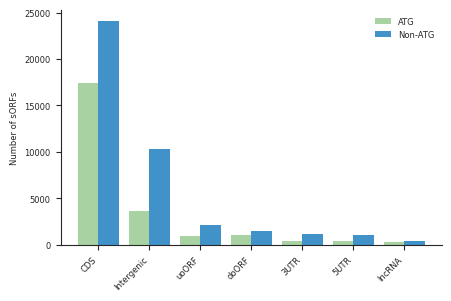

In [23]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

mpl.rcParams.update({
    'font.size': 6,
    'axes.titlesize': 6,
    'axes.labelsize': 6,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 6
})

regions = plot_df.index.tolist()
x = np.arange(len(regions))

width = 0.4

atg_counts = plot_df['ATG'].values
nonatg_counts = plot_df['Non-ATG'].values

fig, ax = plt.subplots(figsize=(4.5, 3))

color_atg =  '#a8d2a2'      
color_nonatg = '#4092c9'  

ax.bar(x - width / 2, atg_counts, width,
       label='ATG', color=color_atg, edgecolor='none')

ax.bar(x + width / 2, nonatg_counts, width,
       label='Non-ATG', color=color_nonatg, edgecolor='none')


ax.set_xticks(x)
ax.set_xticklabels(regions, rotation=45, ha='right')

ax.set_ylabel('Number of sORFs')
# ax.set_xlabel('Genomic Region')
# ax.set_title('Distribution of ATG vs Non-ATG sORFs across Genomic Regions')

ax.legend(frameon=False)

# 去除上、右边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('region_denisity.png',dpi=1300)
plt.show()



findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

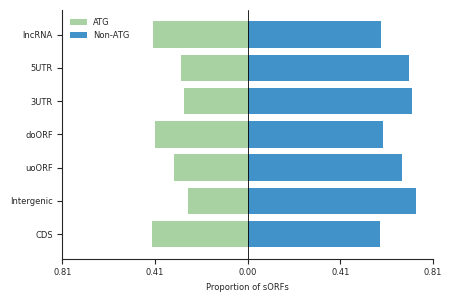

In [24]:
total = atg_counts + nonatg_counts
atg_ratio = atg_counts / total
nonatg_ratio = nonatg_counts / total

fig, ax = plt.subplots(figsize=(4.5, 3))

ax.barh(
    regions,
    -atg_ratio,
    color=color_atg,
    edgecolor='none',
    label='ATG'
)

ax.barh(
    regions,
    nonatg_ratio,
    color=color_nonatg,
    edgecolor='none',
    label='Non-ATG'
)

ax.axvline(0, color='black', linewidth=0.6)

max_ratio = max(atg_ratio.max(), nonatg_ratio.max()) * 1.1
ax.set_xlim(-max_ratio, max_ratio)

ax.set_xticks(np.linspace(-max_ratio, max_ratio, 5))
ax.set_xticklabels([f'{abs(x):.2f}' for x in ax.get_xticks()])

ax.set_xlabel('Proportion of sORFs')

ax.legend(frameon=False, loc='upper left')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
# plt.savefig('region_distribution_mirrored_ATG_left.png', dpi=1300)
plt.show()


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

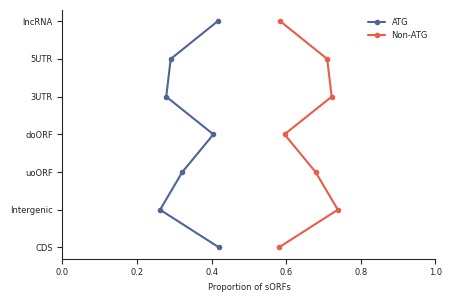

In [43]:
fig, ax = plt.subplots(figsize=(4.5, 3))

ax.plot(atg_ratio, regions, 'o-', color=color_atg, label='ATG', markersize=3)
ax.plot(nonatg_ratio, regions, 'o-', color=color_nonatg, label='Non-ATG', markersize=3)

ax.set_xlabel('Proportion of sORFs')
ax.set_xlim(0, 1)

ax.legend(frameon=False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
# plt.savefig('region_distribution_dot.png', dpi=1300)
plt.show()
